In [41]:
import itertools
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import torch.distributions as D
import numpy as np
from numpy.random import default_rng
import pymc3 as pm
from scipy.stats import vonmises
from scipy.special import i0

from insilico_stimuli.stimuli import GaborSet, CenterSurround

seed = 42
rng = default_rng(seed=seed)
torch.manual_seed(seed=seed)
EPSILON = 1e-12
mpl.style.use("seaborn")
sns.set_palette("colorblind")
sns.set_context("paper")
sns.set_style("darkgrid")
mpl.style.use("seaborn")

# Utilities

In [56]:
def vonmises_pdf(x, mu, kappa):
    return np.exp(kappa * np.cos(x - mu)) / (2 * np.pi * i0(kappa))

def plot_forward_samples(prior_trace, valid_gabors, lambdas):
    fig, axs = plt.subplots(nrows=6, ncols=9, dpi=150, sharex="col")
    # name the first column of the figure as "stimulus" with small font size
    axs[0, 0].set_title("Stimulus", fontsize=6)
    # name rest of columns as "neuron" i
    for i in range(1, 6):
        axs[0, i].set_title(f"Neuron {i}", fontsize=6)
    # name the last column as "global orientation"
    axs[0, 6].set_title("Orientation", fontsize=6)
    axs[0, 7].set_title("Spike rate", fontsize=6)
    axs[0, 8].set_title("Neuron sample", fontsize=6)
    for i, ax in enumerate(axs[:, 0]):
        ax.imshow(prior_trace["stimulus"][i], cmap='gray', vmin=-1, vmax=1)
        ax.axis("off")
    for i, axs_features in enumerate(axs[:, 1:-4]):
        for j, ax in enumerate(axs_features):
            ax.imshow(valid_gabors[j] * prior_trace['neuron'][i][j], cmap='gray', vmin=-1, vmax=1)
            ax.axis("off")
    for i, ax in enumerate(axs[:, -4]):
        # convert orientation to angle and draw line passing through the origin with that angle
        ax.plot([0, np.cos(prior_trace["orientation"][i])], [0, np.sin(prior_trace["orientation"][i])], color="red")
        ax.set_xticks([])
        ax.set_yticks([])
    # plot bar plot of spike rates in the last column but one
    for i, ax in enumerate(axs[:, -3]):
        ax.bar(np.arange(1, 6), lambdas[i], color="blue", alpha=0.5)
        ax.set_xticks([])
        ax.set_yticks([])
    for i, ax in enumerate(axs[:, -2]):
        ax.bar(np.arange(1, 6), prior_trace["neuron"][i], color="red")
        ax.set_xticks([])
        ax.set_yticks([])
    # plot the last column as correlation matrix of neuron samples
    for i, ax in enumerate(axs[:, -1]):
        # plot only lower triangle of correlation matrix
        sns.heatmap(np.corrcoef(prior_trace["neuron"].T), ax=ax, cmap="seismic")
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_aspect("equal")
        # remove the colorbar
        ax.collections[0].colorbar.remove()
    print(prior_trace["orientation"])

def sample_prior(vonmises_loc, vonmises_kappa, n_samples, valid_gabors, valid_orientations):
    n_neurons = len(valid_gabors)

    stimulus_sigma = torch.abs(torch.rand(1)) + EPSILON
    model = pm.Model()
    with model:
        o = pm.Uniform("orientation", upper=np.pi)
        z = pm.Exponential(
            "neuron", 
            lam=vonmises_pdf(o - valid_orientations, vonmises_loc, vonmises_kappa),
            shape=n_neurons
        )
        x = pm.Normal("stimulus", mu=torch.tensor(valid_gabors).permute(1, 2, 0) @ z, sigma=stimulus_sigma, observed=valid_gabors[0])
        prior_trace = pm.sample_prior_predictive(6, random_seed=seed)
    return prior_trace

In [49]:
gabor_locations = [(10, 25), (25, 25), (40, 25)]
gabor_params = {
    "canvas_size"         : [50, 50],
    "sizes"               : [15],
    "spatial_frequencies" : [1/20],
    "contrasts"           : [1.0],
    "grey_levels"         : [0.0],
    "eccentricities"      : [0.0],
    "locations"           : gabor_locations,
    "orientations"        : [0., np.pi/2],  
    "phases"              : [np.pi/2],
    "relative_sf"         : False
}

gabor_set = GaborSet(**gabor_params)

total_param_count = np.prod(gabor_set.num_params())
param_combos = [gabor_set.params_dict_from_idx(idx) for idx in range(total_param_count)]
valid_gabors = np.delete(gabor_set.images(), 2, axis=0)
param_combos.pop(2)
valid_param_combos = param_combos
valid_orientations = np.array([param['orientation'] for param in valid_param_combos])
n_neurons = valid_orientations.shape[0]

In [50]:
vonmises_loc = 0
vonmises_kappa = 1
n_samples = 6
prior_trace = sample_prior(vonmises_loc, vonmises_kappa, n_samples, valid_gabors, valid_orientations)


In [51]:
lambdas = np.array([vonmises_pdf(orientation - valid_orientations, vonmises_loc, vonmises_kappa) for orientation in prior_trace["orientation"]])

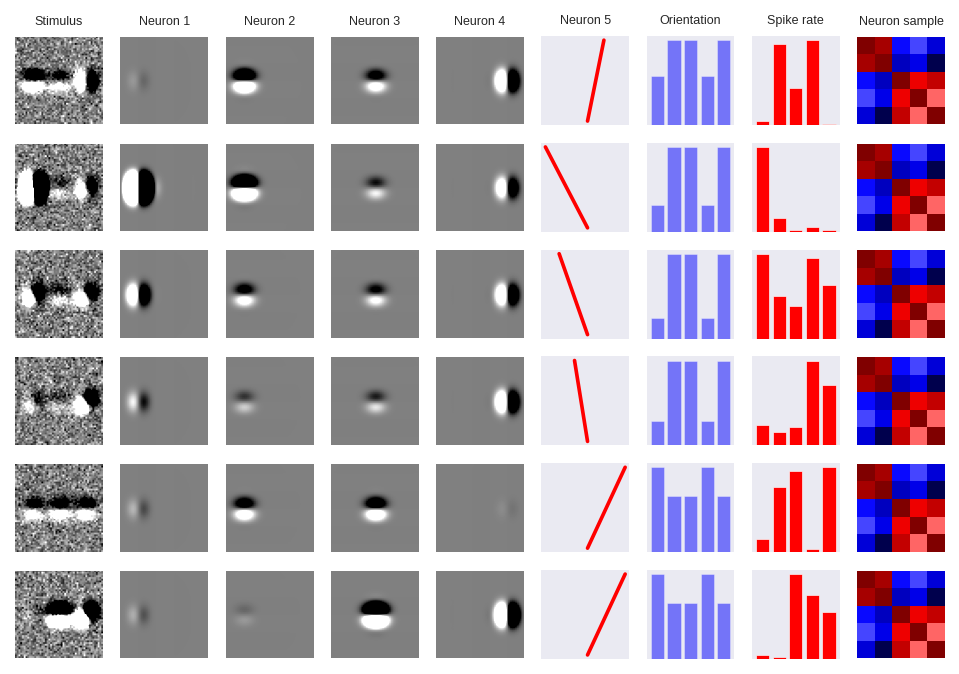

In [52]:
plot_forward_samples(prior_trace, valid_gabors, lambdas)

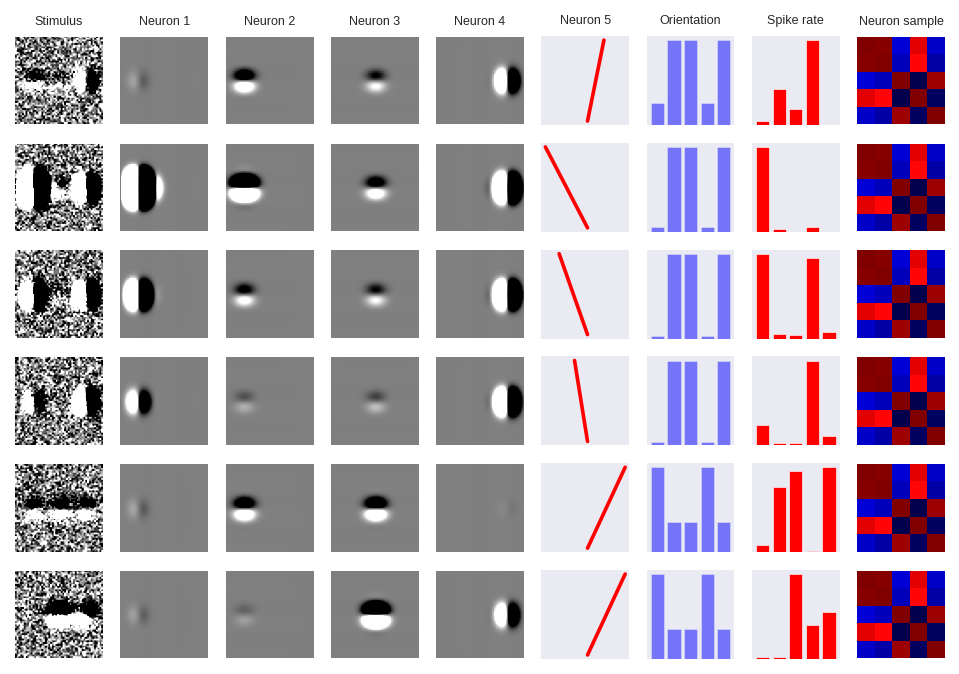

In [53]:
vonmises_loc = 0
vonmises_kappa = 2.5
n_samples = 6
prior_trace = sample_prior(vonmises_loc, vonmises_kappa, n_samples, valid_gabors, valid_orientations)
lambdas = np.array([vonmises_pdf(orientation - valid_orientations, vonmises_loc, vonmises_kappa) for orientation in prior_trace["orientation"]])
plot_forward_samples(prior_trace, valid_gabors, lambdas)

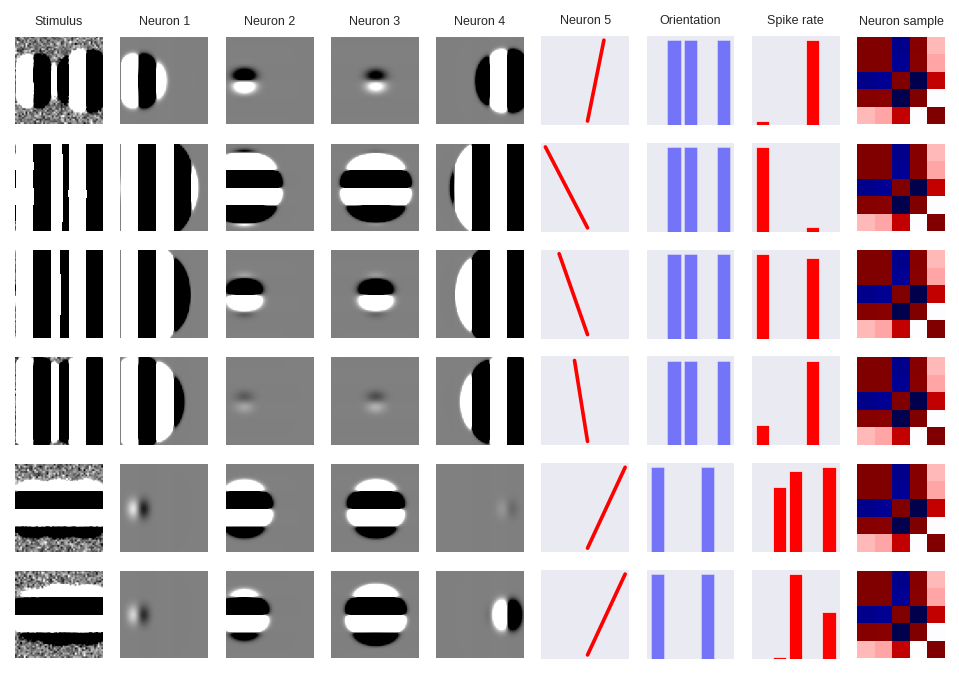

In [54]:
vonmises_loc = 0
vonmises_kappa = 20
n_samples = 6
prior_trace = sample_prior(vonmises_loc, vonmises_kappa, n_samples, valid_gabors, valid_orientations)
lambdas = np.array([vonmises_pdf(orientation - valid_orientations, vonmises_loc, vonmises_kappa) for orientation in prior_trace["orientation"]])
plot_forward_samples(prior_trace, valid_gabors, lambdas)

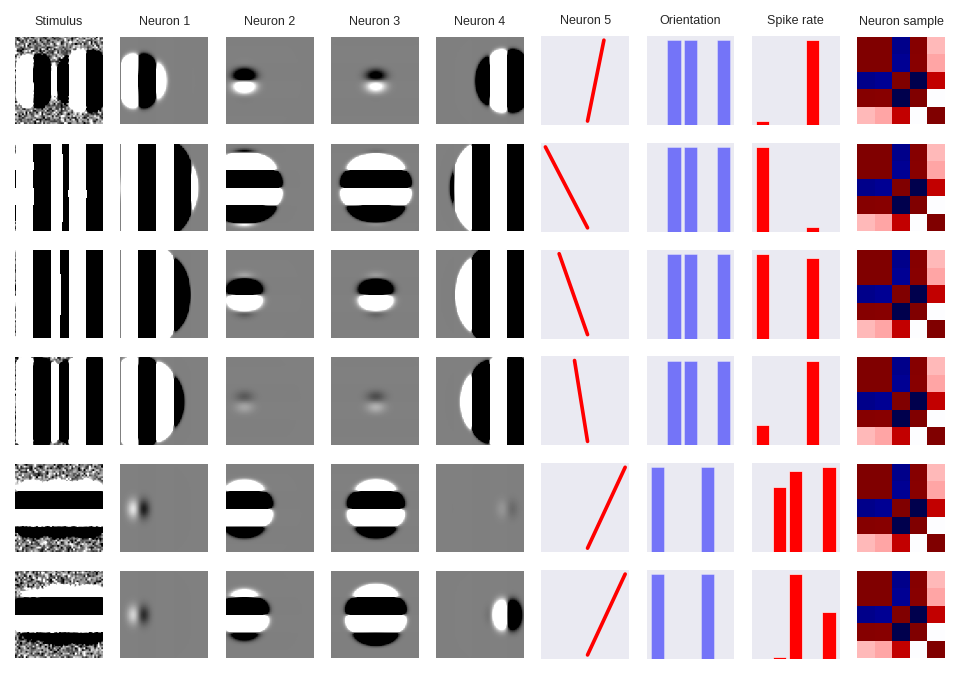

In [55]:
vonmises_loc = 0
vonmises_kappa = 20
n_samples = 6
prior_trace = sample_prior(vonmises_loc, vonmises_kappa, n_samples, valid_gabors, valid_orientations)
lambdas = np.array([vonmises_pdf(orientation - valid_orientations, vonmises_loc, vonmises_kappa) for orientation in prior_trace["orientation"]])
plot_forward_samples(prior_trace, valid_gabors, lambdas)

In [57]:
prior_trace["orientation"]

array([1.17665249, 2.98675708, 2.29962679, 1.8807411 , 0.49014701,
       0.49007124])

(array([2., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0.,
        0., 0., 1.]),
 array([0.49007124, 0.61490553, 0.73973982, 0.86457412, 0.98940841,
        1.1142427 , 1.23907699, 1.36391128, 1.48874558, 1.61357987,
        1.73841416, 1.86324845, 1.98808274, 2.11291704, 2.23775133,
        2.36258562, 2.48741991, 2.6122542 , 2.7370885 , 2.86192279,
        2.98675708]),
 <BarContainer object of 20 artists>)

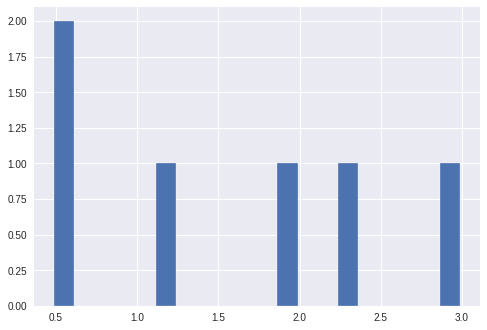

In [58]:
# plot a hist of orientations
plt.hist(prior_trace["orientation"], bins=20)